# 실습 5·6 — HuggingFace Vision 사전학습 모델 (3교시)

**학습 목표**
- 사전학습 모델과 ViT(Vision Transformer)의 핵심 아이디어를 이해한다.
- `pipeline("image-classification")` 1줄로 ImageNet 분류를 수행한다.
- 본인 휴대폰 사진을 직접 분류하고 top-5 확률을 해석한다.
- 분류 실패 사례를 모아 12주차 파인튜닝의 동기를 발견한다.

**사전 조건**
```
pip install torch torchvision transformers datasets pillow matplotlib
```
- 1·2교시 실습 완료 권장 (전처리·증강 개념 이해)
- `sample_images/dog.jpg`, `cat.jpg`, `landscape.jpg` 존재
- (선택) 본인 휴대폰 사진을 `sample_images/` 또는 노트북 폴더에 업로드


## 셀 [0] — 한글 폰트 + 공통 import

In [1]:
import platform
import matplotlib.pyplot as plt
from matplotlib import rcParams

if platform.system() == "Windows":
    rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    rcParams["font.family"] = "AppleGothic"
rcParams["axes.unicode_minus"] = False

## 셀 [1] — `pipeline`으로 ViT 로드

첫 실행 시 약 330MB 다운로드 (1~3분). 다음부터는 캐시에서 즉시 로드.
**환경 자동 감지**: GPU가 있으면 GPU, 없으면 CPU.

In [2]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1

classifier = pipeline(
    task="image-classification",
    model="google/vit-base-patch16-224",
    device=device,
)

print(f"✅ ViT 모델 로드 완료 (실행 장치: {'GPU' if device == 0 else 'CPU'})")

C:\Users\6-112\Desktop\pry\bigdata-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█| 200/
[transformers] `ViTImageProcessor` requires torchvision (not installed); falling back to `ViTImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `ViTImageProcessorPil` directly to silence this warning.


✅ ViT 모델 로드 완료 (실행 장치: CPU)


## 셀 [2] — 강사 샘플 이미지로 첫 분류

`classifier(img, top_k=5)` → `[{'label': ..., 'score': ...}, ...]`

In [3]:
from PIL import Image

img = Image.open("sample_images/dog.jpg").convert("RGB")
result = classifier(img, top_k=5)

for r in result:
    print(f"{r['label']:40s}  →  {r['score']*100:.2f}%")

Labrador retriever                        →  97.72%
golden retriever                          →  0.90%
tennis ball                               →  0.12%
English foxhound                          →  0.08%
dingo, warrigal, warragal, Canis dingo    →  0.07%


## 셀 [3] — 입력 + Top-5 확률 시각화 함수

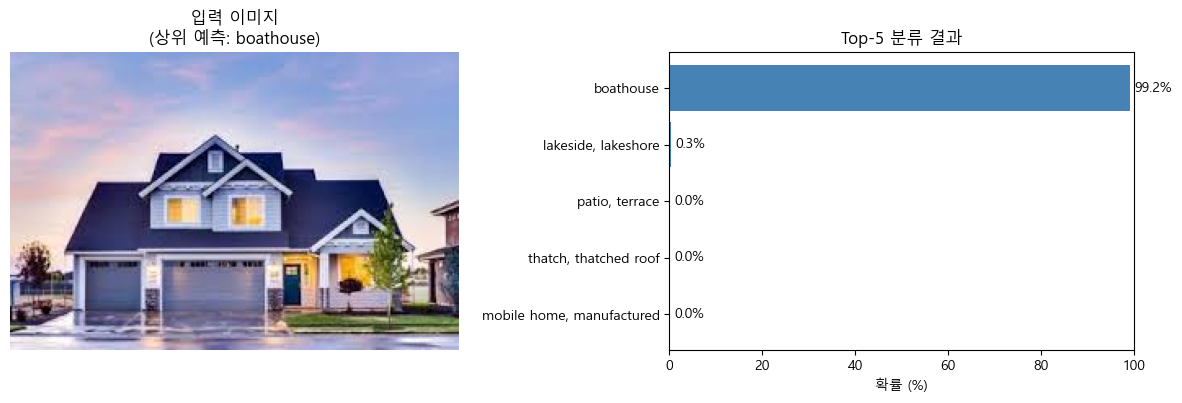

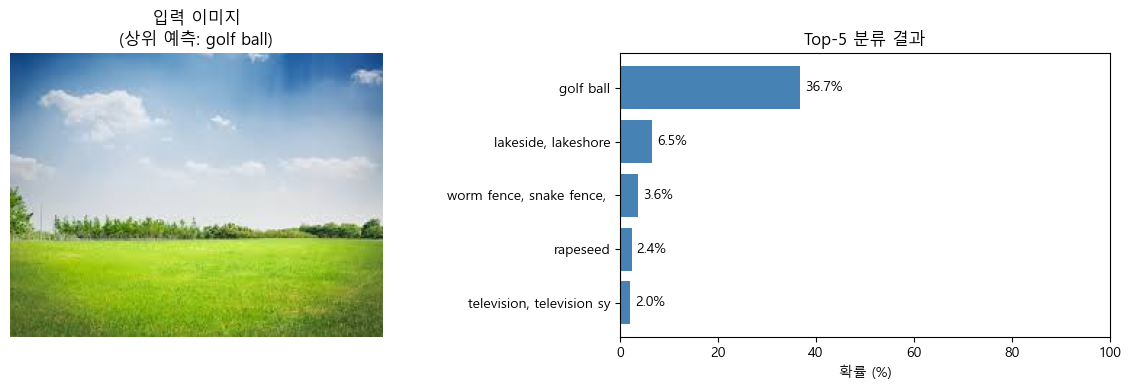

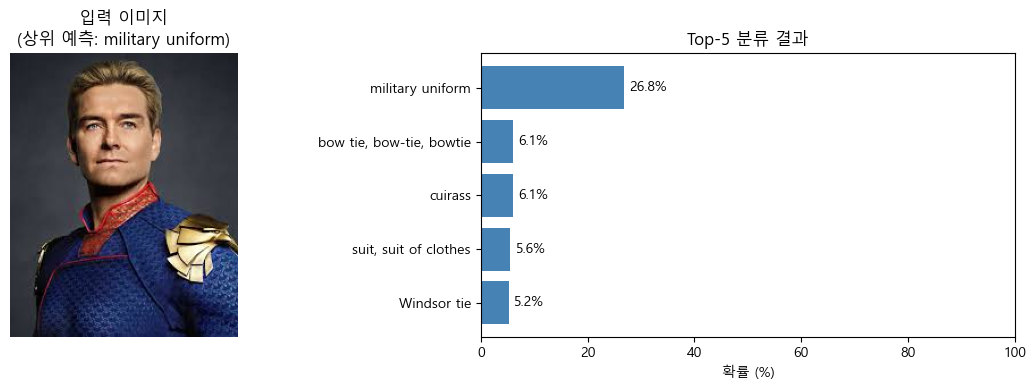

In [4]:
def classify_and_show(image_or_path):
    """이미지(경로 또는 PIL) + 분류 결과 막대그래프를 나란히 표시"""
    if isinstance(image_or_path, str):
        image = Image.open(image_or_path).convert("RGB")
    else:
        image = image_or_path.convert("RGB")

    result = classifier(image, top_k=5)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(image)
    axes[0].set_title(f"입력 이미지\n(상위 예측: {result[0]['label']})")
    axes[0].axis("off")

    labels = [r["label"][:25] for r in result]
    scores = [r["score"] * 100 for r in result]

    axes[1].barh(range(5), scores[::-1], color="steelblue")
    axes[1].set_yticks(range(5))
    axes[1].set_yticklabels(labels[::-1])
    axes[1].set_xlabel("확률 (%)")
    axes[1].set_title("Top-5 분류 결과")
    axes[1].set_xlim(0, 100)
    for i, s in enumerate(scores[::-1]):
        axes[1].text(s + 1, i, f"{s:.1f}%", va="center")

    plt.tight_layout(); plt.show()
    return result

# 강사 샘플 시연
for fname in ["home.jpg", "land.jpg", "homelander.jpg"]:
    path = f"sample_images/{fname}"
    try:
        classify_and_show(path)
    except FileNotFoundError:
        print(f"⚠️ {path} 없음 — sample_images/README.md 참고")

## 셀 [4] — (Colab 전용) 파일 업로드

JupyterLab 사용자는 파일 패널에 드래그&드롭으로 충분. Colab만 아래 코드 필요.

In [5]:
# Colab에서만 실행 (로컬 JupyterLab에서는 그냥 파일을 같은 폴더에 넣으면 됨)
try:
    from google.colab import files
    uploaded = files.upload()
    print("업로드된 파일:", list(uploaded.keys()))
except ImportError:
    print("Colab 환경이 아닙니다. JupyterLab은 좌측 파일 패널에 드래그&드롭 하세요.")

Colab 환경이 아닙니다. JupyterLab은 좌측 파일 패널에 드래그&드롭 하세요.


### 셀 [4-1] — 파일 대신 웹 URL로 분류 (대안)

휴대폰 사진 옮기기가 어려운 경우. URL이 차단되면 동작하지 않을 수 있음.

In [6]:
import requests
from io import BytesIO

url = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"
try:
    web_img = Image.open(BytesIO(requests.get(url, timeout=10).content)).convert("RGB")
    classify_and_show(web_img)
except Exception as e:
    print(f"⚠️ URL 로드 실패: {e}")

⚠️ URL 로드 실패: cannot identify image file <_io.BytesIO object at 0x000001D190AFBDD0>


## 셀 [5] — 내 사진 분류 ★

본인 사진을 같은 폴더에 두고 `my_image` 변수에 파일명을 적으세요.

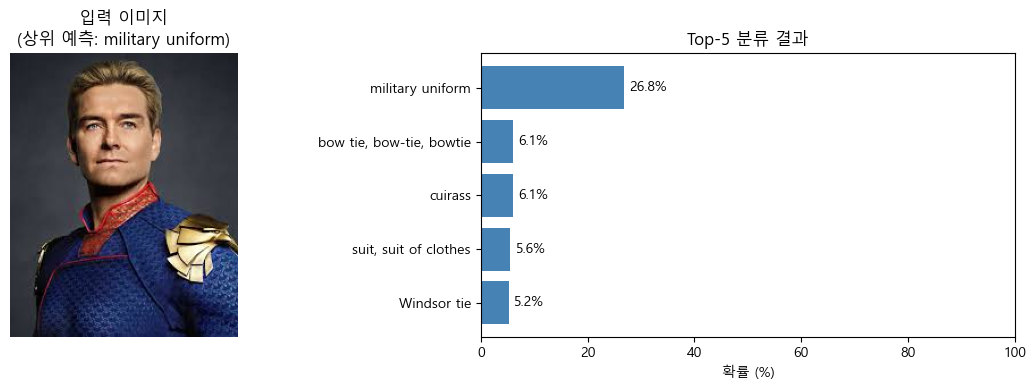


💡 ViT의 결론: 'military uniform' (확신도 26.8%)


In [9]:
import os

# TODO: 본인 사진 파일명으로 바꾸세요
my_image = r"C:\Users\6-112\Desktop\pry\bigdata-project\12_week\sample_images\homelander.jpg"

if not os.path.exists(my_image):
    print(f"⚠️ {my_image} 가 없어서 dog.jpg로 대체 실행합니다.")
    my_image = r"C:\Users\6-112\Desktop\pry\bigdata-project\12_week\sample_images\homelander.jpg"

result = classify_and_show(my_image)
print(f"\n💡 ViT의 결론: '{result[0]['label']}' (확신도 {result[0]['score']*100:.1f}%)")

### 셀 [5-1] — Confidence(확신도) 진단

1위 확률이 얼마면 신뢰할 만한지, Top-2가 의미적으로 가까운지 자동 판단.

In [10]:
def diagnose(result):
    top1, top2 = result[0], result[1]
    conf = top1["score"] * 100
    if conf >= 90:
        print(f"✅ 모델이 매우 확신함 ({conf:.1f}%): '{top1['label']}'")
    elif conf >= 50:
        print(f"🟡 모델이 어느정도 확신 ({conf:.1f}%): '{top1['label']}'")
        print(f"   참고로 2위는 '{top2['label']}' ({top2['score']*100:.1f}%)")
    else:
        print(f"🔴 모델이 헷갈리고 있음 (1위 {conf:.1f}%)")
        print("   상위 5개를 모두 살펴보세요 — 카테고리가 비슷하면 방향은 맞춘 것")
    print()
    for i, r in enumerate(result, 1):
        print(f"  {i}. {r['label']:35s}  {r['score']*100:.2f}%")

diagnose(result)

🔴 모델이 헷갈리고 있음 (1위 26.8%)
   상위 5개를 모두 살펴보세요 — 카테고리가 비슷하면 방향은 맞춘 것

  1. military uniform                     26.82%
  2. bow tie, bow-tie, bowtie             6.10%
  3. cuirass                              6.06%
  4. suit, suit of clothes                5.57%
  5. Windsor tie                          5.22%


## 셀 [6] — 보너스: CIFAR-10으로 정확도 측정 → 한계 발견

ImageNet으로 학습된 ViT를 CIFAR-10에 그대로 적용하면 정확도가 떨어짐 → 12주차 파인튜닝의 동기.

In [12]:
from datasets import load_dataset

cifar_to_imagenet_keywords = {
    "airplane":   ["airliner", "warplane", "wing"],
    "automobile": ["car", "convertible", "sports car"],
    "bird":       ["bird", "robin", "magpie", "jay"],
    "cat":        ["cat", "tabby", "egyptian"],
    "deer":       ["deer", "gazelle", "elk"],
    "dog":        ["dog", "retriever", "spaniel", "terrier"],
    "frog":       ["frog", "toad", "bullfrog"],
    "horse":      ["horse", "pony", "stallion"],
    "ship":       ["ship", "boat", "liner", "yacht"],
    "truck":      ["truck", "trailer", "pickup"],
}

ds = load_dataset("uoft-cs/cifar10")
label_names = ds["test"].features["label"].names

samples = ds["test"].select(range(100))

correct = 0
for item in samples:
    img_i = item["img"].convert("RGB")
    true_label = label_names[item["label"]]
    pred = classifier(img_i, top_k=5)
    pred_labels = [p["label"].lower() for p in pred]

    is_match = any(
        any(kw in pl for pl in pred_labels)
        for kw in cifar_to_imagenet_keywords[true_label]
    )
    if is_match:
        correct += 1

print(f"CIFAR-10 100장 중 매칭: {correct}/100  ({correct}%)")
print("→ 다음 주 파인튜닝(12주차)에서 이 정확도를 끌어올립니다.")

Generating train split: 100%|
Generating test split: 100%|█


CIFAR-10 100장 중 매칭: 72/100  (72%)
→ 다음 주 파인튜닝(12주차)에서 이 정확도를 끌어올립니다.


## 셀 [7] — (선택) ViT의 Attention 시각화

모델이 이미지의 어느 부분에 집중했는지 시각화 — ViT만의 해석성.

In [ ]:
from transformers import ViTImageProcessor, ViTForImageClassification

processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224", output_attentions=True
)
model.eval()

vit_img = Image.open("sample_images/dog.jpg").convert("RGB")
inputs = processor(images=vit_img, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

attn = outputs.attentions[-1]
attn = attn[0].mean(0)
cls_attn = attn[0, 1:]
attn_map = cls_attn.reshape(14, 14).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(vit_img.resize((224, 224)))
axes[0].set_title("원본"); axes[0].axis("off")
axes[1].imshow(vit_img.resize((224, 224)))
axes[1].imshow(attn_map, cmap="jet", alpha=0.5,
               extent=(0, 224, 224, 0))
axes[1].set_title("Attention Map\n(모델이 본 영역)"); axes[1].axis("off")
plt.show()

## 셀 [8] — (도전) 다른 비전 모델과 비교

ViT 외에 ResNet·ConvNeXt·Swin Transformer로 같은 사진을 분류.
모델마다 결과가 살짝 다른 것을 확인 — 앙상블의 출발점.

In [ ]:
models_to_try = [
    "google/vit-base-patch16-224",
    "microsoft/resnet-50",
    "facebook/convnext-base-224",
    "microsoft/swin-base-patch4-window7-224",
]

compare_img = Image.open("sample_images/dog.jpg").convert("RGB")
for model_name in models_to_try:
    try:
        clf = pipeline("image-classification", model=model_name, device=device)
        top1 = clf(compare_img)[0]
        print(f"{model_name:50s}  →  {top1['label']:30s}  ({top1['score']*100:.1f}%)")
    except Exception as e:
        print(f"{model_name:50s}  →  로드 실패 ({type(e).__name__})")

---
## 3교시 마무리 체크리스트

- [ ] 셀 [1]에서 ViT 모델을 1줄로 로드했다.
- [ ] 셀 [2]에서 강아지 사진의 top-5를 출력했다.
- [ ] 셀 [5]에서 본인 사진을 분류하고 결과를 해석했다.
- [ ] 셀 [5-1]에서 Confidence를 기준으로 모델의 확신도를 판단했다.
- [ ] 셀 [6]에서 CIFAR-10 정확도가 ImageNet보다 떨어지는 것을 확인했다.

## 과제: "내 사진 10장 분류 도전기"

1. 본인 사진 **10장 이상** 준비 (동물·음식·풍경·사물 등 다양하게)
2. 각 사진을 `classify_and_show()`로 분류
3. **잘 분류된 사례 3개 + 잘못 분류된 사례 3개** 정리
4. 각 사례에 대해 "왜 이렇게 분류됐을까?" 2~3줄 본인 생각
5. 종합 소감 5줄 이상

**다음 시간(12주차) 예고**: ViT를 우리 데이터(CIFAR-10)에 맞게 **파인튜닝(Fine-tuning)** 합니다.